###Statistics


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("customer_behavior.csv")

In [35]:
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [37]:
df.isnull().sum()

,0
CustomerID,0
Gender,97
Region,175
PurchaseAmount,150
ProductCategory,526
Churn,265
CampaignGroup,185


In [38]:
df.describe()

,CustomerID,PurchaseAmount
count,5000.000000,4850.000000
mean,3500.500000,1003.950670
std,1443.520003,482.113122
min,1001.000000,0.000000
25%,2250.750000,673.642500
50%,3500.500000,998.080000
75%,4750.250000,1327.077500
max,6000.000000,2688.880000


In [39]:
df["PurchaseAmount"].describe()

,PurchaseAmount
count,4850.000000
mean,1003.950670
std,482.113122
min,0.000000
25%,673.642500
50%,998.080000
75%,1327.077500
max,2688.880000


1.Mean,Median and Mode

In [40]:
mean = df["PurchaseAmount"].mean()
median = df["PurchaseAmount"].median()
mode = df["PurchaseAmount"].mode()[0]

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 1003.9506701030928
Median: 998.0799999999999
Mode: 0.0


2.Find Outliers

<Axes: xlabel='PurchaseAmount'>

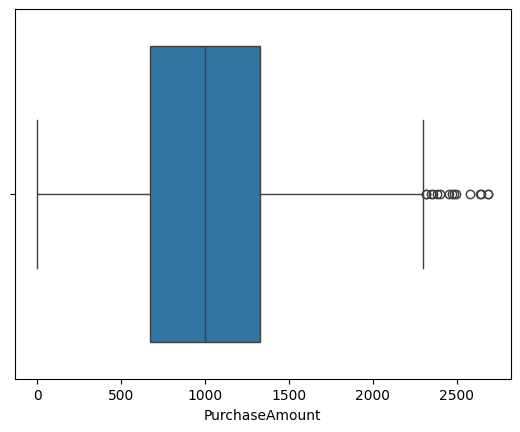

In [41]:
sns.boxplot(x=df["PurchaseAmount"])

In [42]:
Q1 = df["PurchaseAmount"].quantile(0.25)
Q3 = df["PurchaseAmount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 673.6424999999999
Q3: 1327.0775
IQR: 653.4350000000002
Lower limit: -306.51000000000033
Upper limit: 2307.2300000000005


In [43]:
outliers = df[
    (df["PurchaseAmount"] < lower_limit) |
    (df["PurchaseAmount"] > upper_limit)
]

print("Number of outliers:", len(outliers))

Number of outliers: 15


3.Skewness and Kurtosis of PurchaseAmount

In [44]:
skewness = df["PurchaseAmount"].skew()
kurtosis = df["PurchaseAmount"].kurt()

print("Skewness:", round(skewness, 2))
print("Kurtosis:", round(kurtosis, 2))


Skewness: 0.11
Kurtosis: -0.26


4.Compare spending between Male and Female customers

In [45]:
df.groupby("Gender")["PurchaseAmount"].mean().round(2)

,PurchaseAmount
Gender,
Female,987.87
Male,1019.18


Male customer spends more on average.

5.ProductCategory and Churn

In [46]:
table = pd.crosstab(df["ProductCategory"], df["Churn"])
print(table)

Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604


In [47]:
churn_percentage = pd.crosstab(
    df["ProductCategory"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_percentage)

Churn                   No        Yes
ProductCategory                      
Electronics      59.200603  40.799397
Fashion          58.022130  41.977870
Grocery          58.601782  41.398218


6. PurchaseAmount across Regions

In [48]:
region_average = df.groupby("Region")["PurchaseAmount"].mean()
print(region_average)

Region
East     1009.946017
North    1013.017952
South     997.603877
West      995.247327
Name: PurchaseAmount, dtype: float64


In [49]:
print("Highest spending region:", region_average.idxmax())
print("Highest average:", region_average.max())
print("Lowest spending region:", region_average.idxmin())
print("Lowest average:", region_average.min())

Highest spending region: North
Highest average: 1013.0179520137103
Lowest spending region: West
Lowest average: 995.24732735426


7. Which Campaign performed better?

In [50]:
campaign_average = df.groupby("CampaignGroup")["PurchaseAmount"].mean()
print(campaign_average)
print("Better campaign:", campaign_average.idxmax())

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64
Better campaign: A


8.Distribution of Purchase Amount

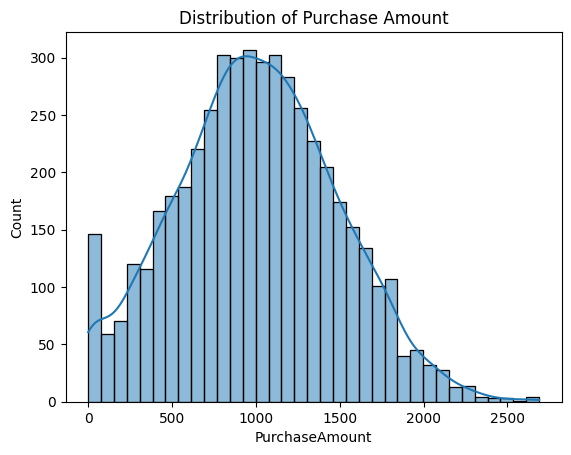

In [51]:
sns.histplot(df["PurchaseAmount"], kde=True)

plt.title("Distribution of Purchase Amount")
plt.show()

9.Central Limit Theorem

In [52]:
import numpy as np

data = df["PurchaseAmount"].dropna()

sample = np.random.choice(data, 30)

print("Population Mean:", data.mean())
print("Sample Mean:", sample.mean())

Population Mean: 1003.9506701030928
Sample Mean: 1009.137


10. 95% Confidence Interval

In [53]:
mean = df["PurchaseAmount"].mean()
std = df["PurchaseAmount"].std()
n = df["PurchaseAmount"].count()

error = 1.96 * (std / (n ** 0.5))

lower = mean - error
upper = mean + error

print("Mean:", mean)
print("95% Confidence Interval:", lower, "to", upper)

Mean: 1003.9506701030928
95% Confidence Interval: 990.3820977717656 to 1017.5192424344199
